In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"

# Blattnamen prüfen und Blatt 2 auswählen
xls = pd.ExcelFile(excel_file, engine="openpyxl")
sheet_name = xls.sheet_names[1]  # 2. Blatt (Index 1)

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AS,AZ",
                   skiprows=14,
                   nrows=16)

df.columns = ["T", "x_wasser"]

Berechneter Schmelzpunkt T*_m aus ΔT_m-Formel: 245.34 K


/var/folders/hd/f5n6dywd28bgfnhwhdf_g_pw0000gn/T/ipykernel_23040/4001017809.py:56: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(T_func, x_wasser, T, p0=initial_guess)


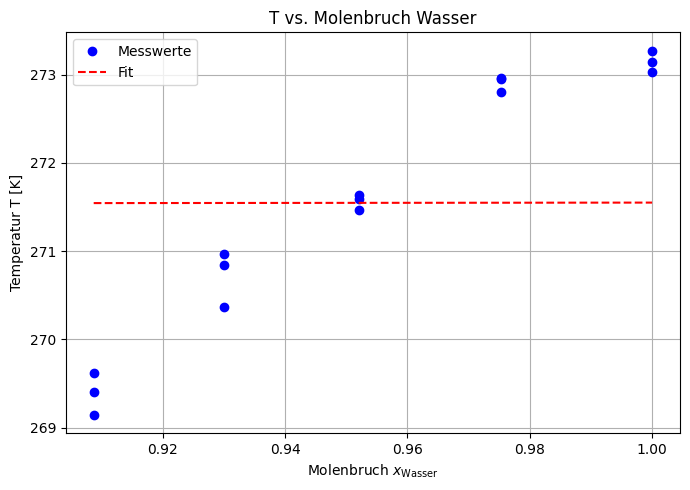

Bestimmte Schmelztemperatur T*_m: 271.55 ± inf K
Bestimmte Schmelzenthalpie ΔH*_m: 6000.00 ± inf J/mol


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt, log
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"
xls = pd.ExcelFile(excel_file, engine="openpyxl")
sheet_name = xls.sheet_names[1]  # 2. Blatt

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AS,AZ",
                   skiprows=14,
                   nrows=16)

df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Werte vorbereiten
# ===============================
T = df["T"].values           # in K
x_wasser = df["x_wasser"].values

# ===============================
# Zusätzliche Berechnung: T*_m aus Formel (3)
# ===============================

# Gegebene oder angenommene Werte:
delta_T_m = 3.0         # Beispiel: 3 K Gefrierpunktserniedrigung
b_salz = 1.0            # Beispiel: 1 mol/kg (molale Konzentration)
delta_H_m = 6010        # z. B. aus vorherigem Fit oder Literatur [J/mol]
M_wasser = 18.015       # [g/mol]
R = 8.314               # Gaskonstante [J/mol·K]

# Umrechnen in SI: M_wasser in kg/mol
M_wasser_kg = M_wasser / 1000  # kg/mol

# Berechnung gemäß umgestellter Gleichung:
Tm_star = np.sqrt((delta_T_m * delta_H_m) / (2 * b_salz * R * M_wasser_kg))

# Ausgabe
print(f"Berechneter Schmelzpunkt T*_m aus ΔT_m-Formel: {Tm_star:.2f} K")

# Anfangsschätzungen
initial_guess = [273.15, 6000]  # Tm in K, ΔH in J/mol

# Fit durchführen
popt, pcov = curve_fit(T_func, x_wasser, T, p0=initial_guess)
Tm_fit, delta_H_fit = popt
Tm_err, delta_H_err = np.sqrt(np.diag(pcov))

# ===============================
# Fit-Kurve
# ===============================
x_fit = np.linspace(min(x_wasser), max(x_wasser), 300)
T_fit = T_func(x_fit, Tm_fit, delta_H_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x_wasser, T, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, T_fit, '--', label=f'Fit', color='red')

plt.xlabel(r"Molenbruch $x_{\mathrm{Wasser}}$")
plt.ylabel("Temperatur T [K]")
plt.title("T vs. Molenbruch Wasser")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse
# ===============================
print(f"Bestimmte Schmelztemperatur T*_m: {Tm_fit:.2f} ± {Tm_err:.2f} K")
print(f"Bestimmte Schmelzenthalpie ΔH*_m: {delta_H_fit:.2f} ± {delta_H_err:.2f} J/mol")

In [12]:
print(df)
print(x_wasser)
print(np.log(x_wasser))

             T  x_wasser
0   273.143333  1.000000
1   273.033333  1.000000
2   273.273333  1.000000
3   272.963333  0.975340
4   272.803333  0.975340
5   272.953333  0.975340
6   271.633333  0.952164
7   271.463333  0.952164
8   271.593333  0.952164
9   270.373333  0.930094
10  270.973333  0.930094
11  270.843333  0.930094
12  269.143333  0.908724
13  269.403333  0.908724
14  269.623333  0.908724
[1.         1.         1.         0.97533998 0.97533998 0.97533998
 0.95216406 0.95216406 0.95216406 0.93009406 0.93009406 0.93009406
 0.90872446 0.90872446 0.90872446]
[ 0.          0.          0.         -0.02496917 -0.02496917 -0.02496917
 -0.04901792 -0.04901792 -0.04901792 -0.07246955 -0.07246955 -0.07246955
 -0.09571335 -0.09571335 -0.09571335]


<>:69: SyntaxWarning: invalid escape sequence '\D'
<>:69: SyntaxWarning: invalid escape sequence '\D'
/var/folders/hd/f5n6dywd28bgfnhwhdf_g_pw0000gn/T/ipykernel_23040/4014558398.py:69: SyntaxWarning: invalid escape sequence '\D'
  plt.title("Fit zur Bestimmung von $T_m^*$ und $\Delta H_m^*$")


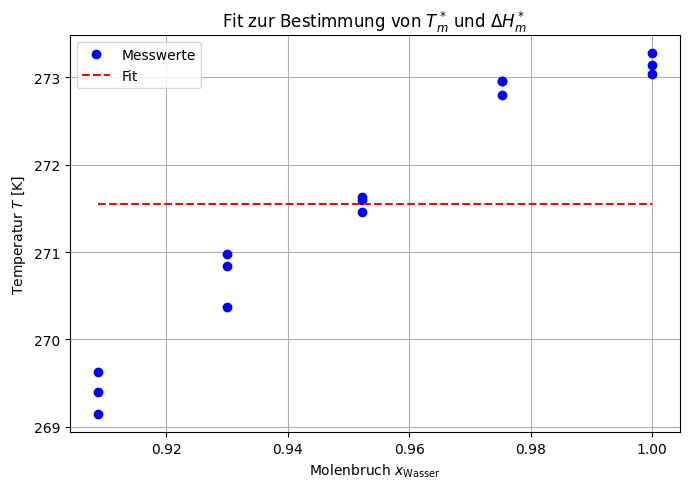

Bestimmter Schmelzpunkt T*_m: 271.55 ± inf K
Bestimmte Schmelzenthalpie ΔH*_m: 52934961867.77 ± inf J/mol


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt, log
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"
xls = pd.ExcelFile(excel_file, engine="openpyxl")
sheet_name = xls.sheet_names[1]  # 2. Blatt

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AS,AZ",  # AS = T, AZ = x_wasser
                   skiprows=14,
                   nrows=16)

df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# Ungültige Werte (z.B. x_wasser <= 0) entfernen, da log(x) sonst nicht definiert
df = df[df["x_wasser"] > 0]

# ===============================
# Werte vorbereiten
# ===============================
T = df["T"].values               # Temperatur in K
x_wasser = df["x_wasser"].values  # Molenbruch des Wassers

# ===============================
# Fit-Funktion: T(x) = 1 / (1/Tm + (R/ΔH) * ln(x))
# ===============================
def T_func(x, Tm, delta_H):
    R = 8.314  # J/mol·K
    return 1 / (1/Tm + (R / delta_H) * np.log(x))

# Startwerte für den Fit (leicht angepasst)
initial_guess = [273.15, 6000]  # Tm in K, ΔH in J/mol

# Fit mit Warnungsunterdrückung (z. B. für schlecht schätzbare Kovarianz)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", OptimizeWarning)
    popt, pcov = curve_fit(T_func, x_wasser, T, p0=initial_guess)

Tm_fit, delta_H_fit = popt
Tm_err, delta_H_err = np.sqrt(np.diag(pcov))

# ===============================
# Fit-Kurve
# ===============================
x_fit = np.linspace(min(x_wasser), max(x_wasser), 300)
T_fit = T_func(x_fit, Tm_fit, delta_H_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x_wasser, T, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, T_fit, '--', label=f'Fit', color='red')

plt.xlabel(r"Molenbruch $x_{\mathrm{Wasser}}$")
plt.ylabel("Temperatur $T$ [K]")
plt.title("Fit zur Bestimmung von $T_m^*$ und $\Delta H_m^*$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse ausgeben
# ===============================
print(f"Bestimmter Schmelzpunkt T*_m: {Tm_fit:.2f} ± {Tm_err:.2f} K")
print(f"Bestimmte Schmelzenthalpie ΔH*_m: {delta_H_fit:.2f} ± {delta_H_err:.2f} J/mol")

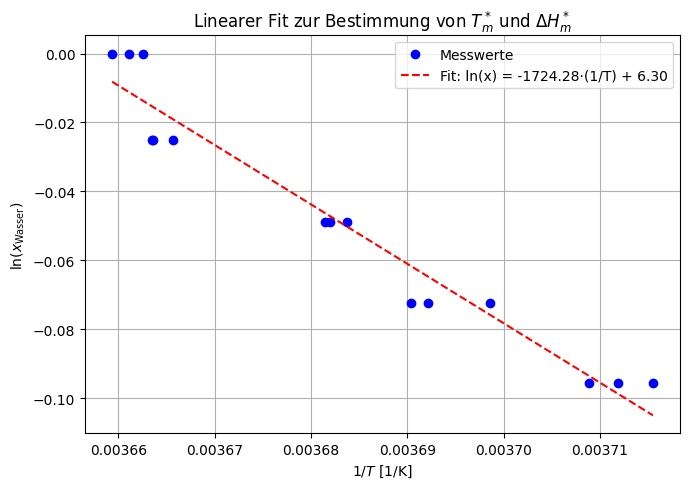

ΔH*_m (Schmelzenthalpie): 14335.68 ± 933.33 J/mol
T*_m (Schmelzpunkt): 273.63 ± 25.29 K


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt, log
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"
xls = pd.ExcelFile(excel_file, engine="openpyxl")
sheet_name = xls.sheet_names[1]  # 2. Blatt (Index 1)

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AS,AZ",  # AS = T [K], AZ = x_wasser
                   skiprows=14,
                   nrows=16)

df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# Nur gültige Werte behalten (log(x) muss definiert sein)
df = df[df["x_wasser"] > 0]

# ===============================
# Werte vorbereiten
# ===============================
T = df["T"].values               # Temperatur in K
x_wasser = df["x_wasser"].values # Molenbruch Wasser

inv_T = 1 / T
ln_x = np.log(x_wasser)

# ===============================
# Linearer Fit: ln(x) = a · (1/T) + b
# ===============================
def lin_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(lin_func, inv_T, ln_x)
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))

# ===============================
# Auswertung
# ===============================
R = 8.314  # J/mol·K
delta_H_m = -a * R
delta_H_m_err = a_err * R

Tm_star = delta_H_m / (R * b)
Tm_star_err = Tm_star * sqrt((delta_H_m_err / delta_H_m)**2 + (b_err / b)**2)

# ===============================
# Plot
# ===============================
x_fit = np.linspace(min(inv_T), max(inv_T), 300)
y_fit = lin_func(x_fit, a, b)

plt.figure(figsize=(7, 5))
plt.plot(inv_T, ln_x, 'o', label="Messwerte", color='blue')
plt.plot(x_fit, y_fit, '--', label=f'Fit: ln(x) = {a:.2f}·(1/T) + {b:.2f}', color='red')

plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(x_{\mathrm{Wasser}})$")
plt.title(r"Linearer Fit zur Bestimmung von $T_m^*$ und $\Delta H_m^*$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse
# ===============================
print(f"ΔH*_m (Schmelzenthalpie): {delta_H_m:.2f} ± {delta_H_m_err:.2f} J/mol")
print(f"T*_m (Schmelzpunkt): {Tm_star:.2f} ± {Tm_star_err:.2f} K")

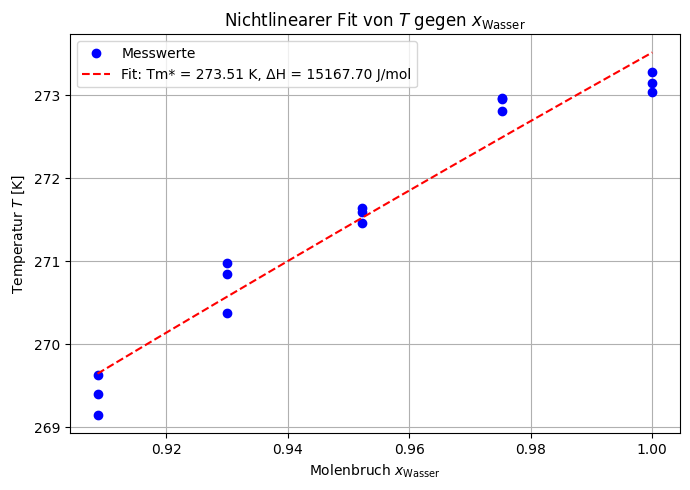

Bestimmter Schmelzpunkt T*_m: 273.51 ± 0.16 K
Bestimmte Schmelzenthalpie ΔH*_m: 15167.70 ± 992.08 J/mol


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt, log
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"
xls = pd.ExcelFile(excel_file, engine="openpyxl")
sheet_name = xls.sheet_names[1]

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AS,AZ",
                   skiprows=14,
                   nrows=16)

df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df[df["x_wasser"] > 0]  # log(x) muss definiert sein

# ===============================
# Werte vorbereiten
# ===============================
T = df["T"].values
x_wasser = df["x_wasser"].values

# ===============================
# Fit-Funktion: T(x) = 1 / (1/Tm + (R/ΔH) * ln(x))
# ===============================
def T_func(x, Tm, delta_H):
    R = 8.314
    return 1 / (1/Tm - (R / delta_H) * np.log(x))

initial_guess = [273.15, 6000]

popt, pcov = curve_fit(T_func, x_wasser, T, p0=initial_guess)
Tm_fit, delta_H_fit = popt
Tm_err, delta_H_err = np.sqrt(np.diag(pcov))

# ===============================
# Fit-Kurve berechnen
# ===============================
x_fit = np.linspace(min(x_wasser), max(x_wasser), 300)
T_fit = T_func(x_fit, Tm_fit, delta_H_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x_wasser, T, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, T_fit, '--', label=f'Fit: Tm* = {Tm_fit:.2f} K, ΔH = {delta_H_fit:.2f} J/mol', color='red')

plt.xlabel(r"Molenbruch $x_{\mathrm{Wasser}}$")
plt.ylabel(r"Temperatur $T$ [K]")
plt.title(r"Nichtlinearer Fit von $T$ gegen $x_{\mathrm{Wasser}}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse
# ===============================
print(f"Bestimmter Schmelzpunkt T*_m: {Tm_fit:.2f} ± {Tm_err:.2f} K")
print(f"Bestimmte Schmelzenthalpie ΔH*_m: {delta_H_fit:.2f} ± {delta_H_err:.2f} J/mol")

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt, log
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei und Blattname
# ===============================
excel_file = "Exp 4 Kryoskopie.xlsx"
xls = pd.ExcelFile(excel_file, engine="openpyxl")
sheet_name = xls.sheet_names[1]

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel(xls,
                   sheet_name=sheet_name,
                   usecols="AS,BA",
                   skiprows=14,
                   nrows=16)

df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df[df["x_wasser"] > 0]  # log(x) muss definiert sein

# ===============================
# Werte vorbereiten
# ===============================
T = df["T"].values
x_wasser = df["x_wasser"].values

# ===============================
# Fit-Funktion: T(x) = 1 / (1/Tm + (R/ΔH) * ln(x))
# ===============================
def T_func(x, Tm, delta_H):
    R = 8.314
    M = 18,01528
    return Tm*(R*Tm**2)/(delta_H)*2*(1-x)     -Tm*delta_H/(R*Tm*np.log(x)-delta_H)

initial_guess = [273.15, 6000]

popt, pcov = curve_fit(T_func, x_wasser, T, p0=initial_guess)
Tm_fit, delta_H_fit = popt
Tm_err, delta_H_err = np.sqrt(np.diag(pcov))

# ===============================
# Fit-Kurve berechnen
# ===============================
x_fit = np.linspace(min(x_wasser), max(x_wasser), 300)
T_fit = T_func(x_fit, Tm_fit, delta_H_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x_wasser, T, 'o', label='Messwerte', color='blue')
plt.plot(x_fit, T_fit, '--', label=f'Fit: Tm* = {Tm_fit:.2f} K, ΔH = {delta_H_fit:.2f} J/mol', color='red')

plt.xlabel(r"Molenbruch $x_{\mathrm{Wasser}}$")
plt.ylabel(r"Temperatur $T$ [K]")
plt.title(r"Nichtlinearer Fit von $T$ gegen $x_{\mathrm{Wasser}}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse
# ===============================
print(f"Bestimmter Schmelzpunkt T*_m: {Tm_fit:.2f} ± {Tm_err:.2f} K")
print(f"Bestimmte Schmelzenthalpie ΔH*_m: {delta_H_fit:.2f} ± {delta_H_err:.2f} J/mol")

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (2896381487.py, line 38)

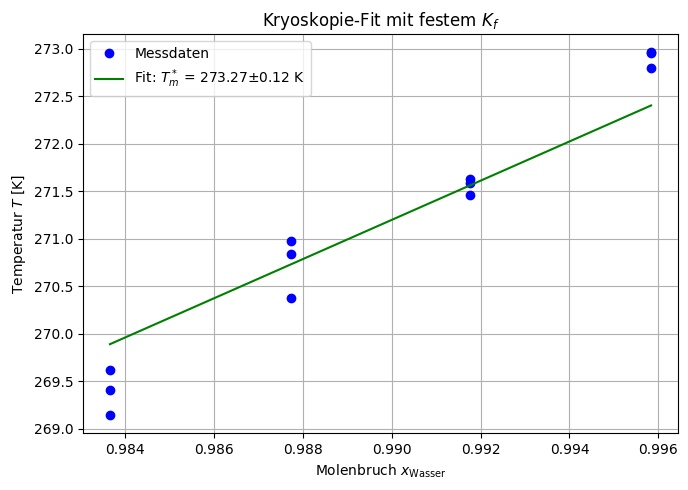

Gefitteter Schmelzpunkt T*_m: 273.27 ± 0.12 K
Berechnete Schmelzenthalpie ΔH: 6013.11 ± 5.22 J/mol


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Konstanten
# ===============================
K_f = 1860  # K·kg/mol für Wasser
M_water = 18.015  # g/mol
R = 8.314  # J/mol/K

# ===============================
# Excel-Datei einlesen
# ===============================
xls = pd.ExcelFile("Exp 4 Kryoskopie.xlsx", engine="openpyxl")
df = pd.read_excel(xls, sheet_name=xls.sheet_names[1],
                   usecols="AS,BA", skiprows=17, nrows=16)

df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df[df["x_wasser"] > 0]

T = df["T"].values
x = df["x_wasser"].values

# ===============================
# Fit-Funktion mit festem K_f
# ===============================
def T_fit_func(x, Tm):
    return Tm - (2 * K_f / M_water) * (1 - x)

# Fit nur für Tm
initial_guess = [273.15]
popt, pcov = curve_fit(T_fit_func, x, T, p0=initial_guess)
Tm_fit = popt[0]
Tm_err = np.sqrt(pcov[0, 0])

# ===============================
# Schmelzenthalpie berechnen
# ===============================
delta_H = (R * Tm_fit**2 * M_water) / K_f
delta_H_err = (2 * R * Tm_fit * M_water / K_f) * Tm_err  # Fehler über Gauss

# ===============================
# Fit-Kurve berechnen
# ===============================
x_fit = np.linspace(min(x), max(x), 300)
T_model = T_fit_func(x_fit, Tm_fit)

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, T, 'o', color='blue', label="Messdaten")
plt.plot(x_fit, T_model, '-', color='green',
         label=fr'Fit: $T^*_m$ = {Tm_fit:.2f}±{Tm_err:.2f} K')

plt.xlabel(r"Molenbruch $x_{\mathrm{Wasser}}$")
plt.ylabel("Temperatur $T$ [K]")
plt.title("Kryoskopie-Fit mit festem $K_f$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe
# ===============================
print(f"Gefitteter Schmelzpunkt T*_m: {Tm_fit:.2f} ± {Tm_err:.2f} K")
print(f"Berechnete Schmelzenthalpie ΔH: {delta_H:.2f} ± {delta_H_err:.2f} J/mol")

In [2]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Konstanten
R = 8.314  # J/mol/K

# Daten laden
xls = pd.ExcelFile("Exp 4 Kryoskopie.xlsx", engine="openpyxl")
df = pd.read_excel(xls, sheet_name=xls.sheet_names[1],
                   usecols="AS,BA", skiprows=14, nrows=20)
df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df[df["x_wasser"] > 0]

x = df["x_wasser"].values
T = df["T"].values

# Kryoskopische Konstante von Wasser (in K·kg/mol)
K_f = 1.86
# Massen Wasser (g) konstant
m_wasser = 20.1317  # g

# Molmassen
M_wasser = 18.015  # g/mol
M_salz = 107.05    # g/mol

# Salzmassen je Konzentration
m_salz_dict = {
   2.5: 0.5090,
   5.0: 1.0114,
   7.5: 1.5131,
   10.0: 2.0221
}
# Modellfunktion definieren
def T_model(x, Tm, delta_H):
    return Tm - (R * Tm**2 / delta_H) * (1 - x)

# Gefrierpunktserniedrigung berechnen
delta_Tm_dict = {}
for c, m_s in m_salz.items():
    delta_Tm_dict[c] = (2 * K_f / M_salz) * (m_s / m_wasser)

# Ausgabe ΔT_m
print("Gefrierpunktserniedrigung ΔT_m für verschiedene Konzentrationen:")
for c, dt in delta_Tm_dict.items():
    print(f"{c:.1f} g Salz: ΔT_m = {dt:.4f} K")

# Startwerte
popt, pcov = curve_fit(T_model, x, T, p0=[273.15, 6000], bounds=([270, 1000], [275, 8000]))
Tm_fit, delta_H_fit = popt
Tm_err, delta_H_err = np.sqrt(np.diag(pcov))

# Fit-Kurve
x_fit = np.linspace(min(x), max(x), 300)
T_fit = T_model(x_fit, Tm_fit, delta_H_fit)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(x, T, 'o', label="Messdaten", color="blue")
plt.plot(x_fit, T_fit, '-', label=fr'Fit: $T^*_m$ = {Tm_fit:.2f} K, ΔH = {delta_H_fit:.2f} J/mol', color="green")
plt.xlabel(r"Molenbruch $x_{\mathrm{Wasser}}$")
plt.ylabel("Temperatur $T$ [K]")
plt.grid(True)
plt.legend()
plt.title("Fit: Temperatur als Funktion des Molenbruchs")
plt.tight_layout()
plt.show()

# Ausgabe
print(f"Fit-Ergebnis: Tm = {Tm_fit:.2f} ± {Tm_err:.2f} K")
print(f"Schmelzenthalpie ΔH = {delta_H_fit:.2f} ± {delta_H_err:.2f} J/mol")



NameError: name 'm_salz' is not defined

ΔH_m* = 4468.5 ± 147.4 J/mol
T_m* = 274.23 ± 0.10 K


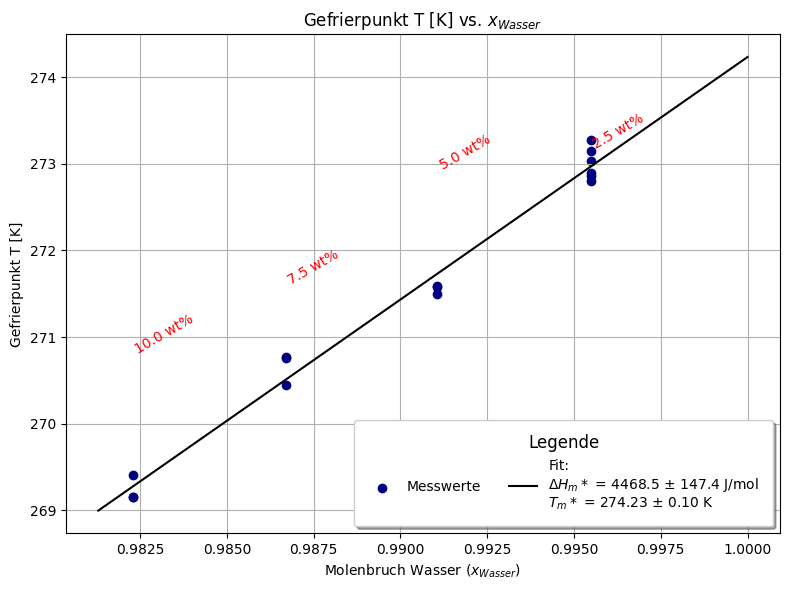

15 15


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Konstanten
R = 8.314  # J/(mol*K)

# Gegebene korrigierte Gefrierpunkte in Kelvin
T_K = np.array([
    273.143, 273.033, 273.273,
   272.893, 272.803, 272.863,   # 2.5 wt%
   271.573, 271.493, 271.593,   # 5 wt%
   270.773, 270.753, 270.443,   # 7.5 wt%
   269.153, 269.403, 269.153    # 10 wt%
])

# Massen Wasser (g) konstant
m_water = 20.01  # g

# Molmassen
M_water = 18.015  # g/mol
M_salt = 101.0    # g/mol

# Salzmassen je Konzentration
m_salt_dict = {
   2.5: 0.509,
   5.0: 1.0114,
   7.5: 1.5131,
   10.0: 2.0221
}

# Funktion zur Berechnung des Molenbruchs Wasser x_Wasser
def calc_x_water(m_salt):
   n_water = m_water / M_water
   n_salt = m_salt / M_salt
   return n_water / (n_water + n_salt)

# Berechnung aller x_Wasser Werte für jede Messung
x_water_vals = (
   [calc_x_water(m_salt_dict[2.5])] * 3 +
   [calc_x_water(m_salt_dict[2.5])] * 3 +
   [calc_x_water(m_salt_dict[5.0])] * 3 +
   [calc_x_water(m_salt_dict[7.5])] * 3 +
   [calc_x_water(m_salt_dict[10.0])] * 3
)
x_water_vals = np.array(x_water_vals)

# Kryoskopische Konstante von Wasser (in K·kg/mol)
K_f = 1.86

# Gefrierpunktserniedrigung berechnen
delta_Tm = (2 * K_f / M_salz) * (m_salz / m_wasser)

# Startwerte für Fit
initial_guess = [6000, 273.15]

# Fit durchführen
params, covariance = curve_fit(freezing_model, x_water_vals, T_K, p0=initial_guess)
delta_H_fit, T_m_fit = params

# Unsicherheiten der Parameter (Standardabweichungen)
errors = np.sqrt(np.diag(covariance))
delta_H_err, T_m_err = errors

print(f"ΔH_m* = {delta_H_fit:.1f} ± {delta_H_err:.1f} J/mol")
print(f"T_m* = {T_m_fit:.2f} ± {T_m_err:.2f} K")

# Fitkurve zum Plotten
x_fit = np.linspace(min(x_water_vals) - 0.001, 1, 300)
T_fit = freezing_model(x_fit, delta_H_fit, T_m_fit)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x_water_vals, T_K, color='navy', label='Messwerte')
plt.plot(x_fit, T_fit, color='black',
        label=f'Fit:\n$ΔH_m*$ = {delta_H_fit:.1f} ± {delta_H_err:.1f} J/mol\n$T_m*$ = {T_m_fit:.2f} ± {T_m_err:.2f} K')

# Labels: nur ein Punkt pro wt%
unique_wt = [2.5, 5.0, 7.5, 10.0]
for wt in unique_wt:
   x_label = calc_x_water(m_salt_dict[wt])
   # Erster Messwert des jeweiligen wt% (Index berechnen)
   idx = {2.5:0, 5.0:3, 7.5:6, 10.0:9}[wt]
   T_label = T_K[idx]
   plt.text(x_label, T_label, f"{wt} wt%", fontsize=10, ha='left', va='bottom', rotation=30, color='red')

plt.xlabel('Molenbruch Wasser ($x_{Wasser}$)')
plt.ylabel('Gefrierpunkt T [K]')
plt.title('Gefrierpunkt T [K] vs. $x_{Wasser}$')
plt.grid(True)
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True,
          borderpad=1, ncol=2, title='Legende', title_fontsize=12)
plt.tight_layout()
plt.show()
print(len(x_water_vals), len(T_K))

Gefrierpunktserniedrigung ΔT_m (nur Info):
 2.5 g Salz → ΔT_m = 0.0009 K
 5.0 g Salz → ΔT_m = 0.0017 K
 7.5 g Salz → ΔT_m = 0.0026 K
10.0 g Salz → ΔT_m = 0.0035 K



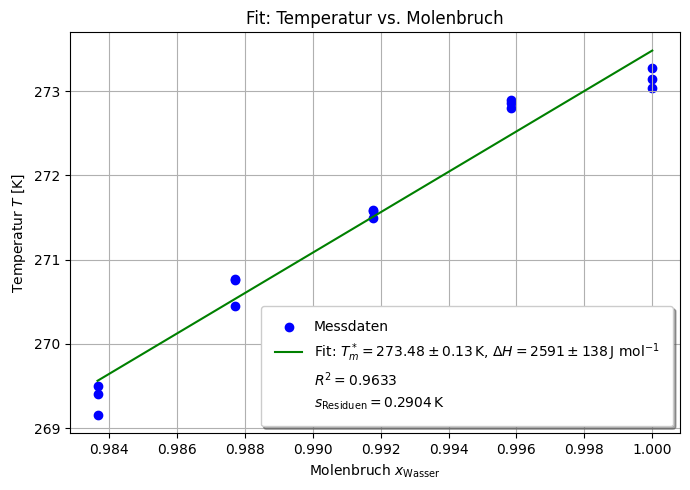

Fit-Ergebnis und Statistik
  Tm          = 273.48 ± 0.13  K
  ΔH          = 2591.38 ± 138.35  J mol⁻¹
  R²          = 0.9633
  s (RMSE)    = 0.2904 K


In [4]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# Konstanten
# --------------------------------------------------
R = 8.314  # J mol⁻¹ K⁻¹
K_f = 1.86           # Kryoskopische Konstante von Wasser, K·kg·mol⁻¹
m_wasser = 20.1317   # g
M_salz   = 107.05    # g·mol⁻¹

# --------------------------------------------------
# Daten laden
# --------------------------------------------------
xls = pd.ExcelFile("Exp 4 Kryoskopie.xlsx", engine="openpyxl")
df  = pd.read_excel(xls, sheet_name=xls.sheet_names[1],
                    usecols="AS,BA", skiprows=14, nrows=20)
df.columns = ["T", "x_wasser"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df[df["x_wasser"] > 0]

x = df["x_wasser"].values          # Molenbruch Wasser
T = df["T"].values                 # Temperatur in K

# --------------------------------------------------
# optionale Info: ΔT_m aus Tabellenwerten (nicht für den Fit genutzt)
# --------------------------------------------------
m_salz_dict = {2.5: 0.5090, 5.0: 1.0114, 7.5: 1.5131, 10.0: 2.0221}
print("Gefrierpunktserniedrigung ΔT_m (nur Info):")
for c, m_s in m_salz_dict.items():
    ΔT_m = (2 * K_f / M_salz) * (m_s / m_wasser)
    print(f"{c:4.1f} g Salz → ΔT_m = {ΔT_m:.4f} K")
print()

# --------------------------------------------------
# Modell definieren
# --------------------------------------------------
def T_model(x, Tm, ΔH):
    """Raoult/van - ’t Hoff – vereinfachtes Modell"""
    return Tm - (R * Tm**2 / ΔH) * (1 - x)

# --------------------------------------------------
# Nichtlinearer Fit
# --------------------------------------------------
popt, pcov = curve_fit(
    T_model, x, T,
    p0=[273.15, 6000], bounds=([270, 1000], [275, 8000])
)
Tm_fit, ΔH_fit = popt
σ_Tm, σ_ΔH     = np.sqrt(np.diag(pcov))   # 1-σ-Unsicherheiten

# --------------------------------------------------
# Qualitätskennzahlen
# --------------------------------------------------
T_calc   = T_model(x, *popt)
residuen = T - T_calc

SS_res = np.sum(residuen**2)
SS_tot = np.sum((T - np.mean(T))**2)
R2     = 1 - SS_res / SS_tot

n       = len(x)
p       = len(popt)          # Anzahl Fit-Parameter
s       = np.sqrt(SS_res / (n - p))   # Residuen-Stdabw. / RMSE

# --------------------------------------------------
# Fit-Kurve zum Plotten
# --------------------------------------------------
x_plot = np.linspace(x.min(), x.max(), 300)
T_plot = T_model(x_plot, *popt)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(x, T,  color="blue", label="Messdaten")
plt.plot(x_plot, T_plot, color="green",
         label=fr"Fit: $T_m^*={Tm_fit:.2f}\pm{σ_Tm:.2f}\,$K, "
               fr"$\Delta H={ΔH_fit:.0f}\pm{σ_ΔH:.0f}\,$J mol$^{{-1}}$")

# Zusatzinfos in der Legende
plt.plot([], [], ' ', label=fr"$R^2={R2:.4f}$")
plt.plot([], [], ' ', label=fr"$s_{{\mathrm{{Residuen}}}}={s:.4f}\,$K")

plt.xlabel(r"Molenbruch $x_{\mathrm{Wasser}}$")
plt.ylabel(r"Temperatur $T$ [K]")
plt.title("Fit: Temperatur vs. Molenbruch")
plt.grid(True)
plt.legend(frameon=True, shadow=True, borderpad=1)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Konsolenausgabe
# --------------------------------------------------
print("Fit-Ergebnis und Statistik")
print(f"  Tm          = {Tm_fit:.2f} ± {σ_Tm:.2f}  K")
print(f"  ΔH          = {ΔH_fit:.2f} ± {σ_ΔH:.2f}  J mol⁻¹")
print(f"  R²          = {R2:.4f}")
print(f"  s (RMSE)    = {s:.4f} K")